# Testing GRU Network

In [7]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# Add current working directory to Python path
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

print(f"Added to path: {current_dir}")

Added to path: c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\gru_autoencoder


In [8]:
"""
GRU Implementation for Single Water Meter Anomaly Detection
Uses harmonic features (sin/cos) + delta_time as inputs instead of decay mechanisms
Handles irregular timestamps naturally without forcing forgetting

UPDATED: window_size is now a configurable parameter passed throughout
"""


class GRUNet(nn.Module):
    """
    Standard GRU Network for Time Series Forecasting with Irregular Data
    
    Input features:
    - Meter reading (normalized)
    - Delta time since last reading (normalized)
    - Time of day harmonics: sin(2π*hour/24), cos(2π*hour/24)
    - Day of week harmonics: sin(2π*day/7), cos(2π*day/7)
    
    Total input size: 1 (value) + 1 (delta_t) + 2 (TOD sin/cos) + 2 (DOW sin/cos) = 6 features
    
    Output: Predicted meter reading
    
    Advantages over decay-based methods:
    - Model learns when to ignore/attend to features naturally
    - Handles frequent short irregularities (30min vs 1h) gracefully
    - Cyclic patterns explicitly encoded
    - No hard-coded "forgetting" mechanism
    """
    def __init__(self, input_size=6, hidden_size=32, num_layers=1, dropout=0.1):
        super(GRUNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # GRU stack
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        
        # Output layer
        self.fc_out = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        """
        Args:
            x: Input tensor (batch_size, seq_len, 6)
               Features: [value, delta_t, sin_tod, cos_tod, sin_dow, cos_dow]
        
        Returns:
            output: Predictions (batch_size, seq_len, 1)
        """
        # GRU forward pass
        gru_out, _ = self.gru(x)  # (batch_size, seq_len, hidden_size)
        
        # Output projection
        output = self.fc_out(gru_out)  # (batch_size, seq_len, 1)
        
        return output


class MeterDataset(Dataset):
    """
    PyTorch Dataset for water meter time series with harmonic features
    
    Handles:
    - Creating sliding windows
    - Computing time deltas between observations
    - Computing harmonic features (time-of-day, day-of-week)
    - Normalization
    """
    def __init__(self, df, window_size=48, train=True, scaler=None):
        """
        Args:
            df: DataFrame with columns ['timestamp', 'Diff']
            window_size: Number of consecutive readings per window (e.g., 48 ~ 1 day for 30min intervals)
            train: If True, compute scaler; if False, use provided scaler
            scaler: StandardScaler object (required if train=False)
        """
        self.df = df.copy()
        self.window_size = window_size
        
        # Sort by timestamp
        self.df['timestamp'] = pd.to_datetime(self.df['timestamp'])
        self.df = self.df.sort_values('timestamp').reset_index(drop=True)
        
        # ===== Compute time deltas (in hours) =====
        self.df['time_delta'] = self.df['timestamp'].diff().dt.total_seconds() / 3600.0
        self.df['time_delta'].fillna(0, inplace=True)
        
        # ===== Handle missing values =====
        self.df['is_missing'] = self.df['Diff'].isna().astype(float)
        
        # Forward fill missing Diff values
        self.df['Diff'].fillna(method='ffill', inplace=True)
        self.df['Diff'].fillna(0, inplace=True)
        
        # ===== Normalize meter readings =====
        if train:
            self.scaler = StandardScaler()
            self.df['Diff_norm'] = self.scaler.fit_transform(self.df[['Diff']])
        else:
            assert scaler is not None, "Must provide scaler if train=False"
            self.scaler = scaler
            self.df['Diff_norm'] = self.scaler.transform(self.df[['Diff']])
        
        # ===== Normalize time delta: cap at 24 hours and normalize to [0, 1] =====
        self.df['time_delta_capped'] = np.clip(self.df['time_delta'], 0, 24)
        self.df['time_delta_norm'] = self.df['time_delta_capped'] / 24.0
        
        # ===== Compute harmonic features =====
        # Time of day (0-23 hours)
        hours = self.df['timestamp'].dt.hour + self.df['timestamp'].dt.minute / 60.0
        self.df['sin_tod'] = np.sin(2 * np.pi * hours / 24.0)
        self.df['cos_tod'] = np.cos(2 * np.pi * hours / 24.0)
        
        # Day of week (0-6, Monday=0, Sunday=6)
        dow = self.df['timestamp'].dt.dayofweek
        self.df['sin_dow'] = np.sin(2 * np.pi * dow / 7.0)
        self.df['cos_dow'] = np.cos(2 * np.pi * dow / 7.0)
        
        self.max_idx = len(self.df) - self.window_size
    
    def __len__(self):
        return max(1, self.max_idx)
    
    def __getitem__(self, idx):
        """
        Returns a window of data as tensors
        
        Returns:
            x: Feature tensor (window_size, 6)
               Features: [Diff_norm, time_delta_norm, sin_tod, cos_tod, sin_dow, cos_dow]
            actual_values: Raw meter readings for loss computation
        """
        idx = min(idx, self.max_idx)
        start_idx = idx
        end_idx = idx + self.window_size
        
        window = self.df.iloc[start_idx:end_idx]
        
        # Stack all features
        x = torch.stack([
            torch.tensor(window['Diff_norm'].values, dtype=torch.float32),
            torch.tensor(window['time_delta_norm'].values, dtype=torch.float32),
            torch.tensor(window['sin_tod'].values, dtype=torch.float32),
            torch.tensor(window['cos_tod'].values, dtype=torch.float32),
            torch.tensor(window['sin_dow'].values, dtype=torch.float32),
            torch.tensor(window['cos_dow'].values, dtype=torch.float32),
        ], dim=1)  # (window_size, 6)
        
        actual_values = torch.tensor(window['Diff_norm'].values, dtype=torch.float32)
        
        return x, actual_values


def train_gru_model(df, window_size=48, model_path=None, epochs=50, batch_size=32, 
                    hidden_size=32, learning_rate=1e-3, loss_function='mae', device=None, 
                    pretrained_model_path=None):
    """
    Train a GRU model on a single meter's data with harmonic features
    Supports warm-start training from a previously trained model
    
    Args:
        df: DataFrame with columns ['timestamp', 'Diff']
        window_size: Number of consecutive readings per window (e.g., 48 for ~1 day at 30min intervals)
        model_path: Path to save the model (optional)
        epochs: Number of training epochs (default: 50 for initial, use also for retrain)
        batch_size: Batch size for training
        hidden_size: Hidden size of GRU
        learning_rate: Learning rate
        loss_function: Loss function to use ('mae' or 'mse'). Default: 'mae' for robustness
                       MAE is recommended for anomaly detection to avoid outlier overfitting
        device: torch device (cpu or cuda)
        pretrained_model_path: Path to load pre-trained model weights (for warm-start retraining)
                              If provided, model will be initialized with these weights
    
    Returns:
        model: Trained GRU model
        scaler: StandardScaler used for normalization
        losses: List of average losses per epoch
        training_info: Dict with info about training (is_warmstart, total_epochs, etc.)
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Determine number of epochs to train
    is_warmstart = pretrained_model_path is not None
    
    print(f"\nUsing device: {device}")
    print(f"Dataset size: {len(df)} readings")
    print(f"Window size: {window_size}")
    
    # Create dataset and dataloader
    dataset = MeterDataset(df, window_size=window_size, train=True)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    scaler = dataset.scaler
    
    # Initialize model with 6 input features
    model = GRUNet(input_size=6, hidden_size=hidden_size, num_layers=1, dropout=0.1)
    model = model.to(device)
    
    # Load pretrained weights if provided (warm-start)
    if is_warmstart:
        try:
            # PyTorch 2.6+ requires weights_only=False for non-tensor objects like StandardScaler
            checkpoint = torch.load(pretrained_model_path, map_location=device, weights_only=False)
        except TypeError:
            # Fallback for older PyTorch versions that don't have weights_only parameter
            checkpoint = torch.load(pretrained_model_path, map_location=device)
        
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✅ Loaded pretrained weights from {pretrained_model_path}")
        print(f"   Model will fine-tune on new data")
        
    
    # Loss function selection
    if loss_function.lower() == 'mae':
        criterion = nn.L1Loss()  # MAE loss
        print(f"📊 Using MAE (L1) Loss - Robust to outliers")
    elif loss_function.lower() == 'mse':
        criterion = nn.MSELoss()  # MSE loss
        print(f"📊 Using MSE Loss - Standard squared error")
    else:
        raise ValueError(f"loss_function must be 'mae' or 'mse', got '{loss_function}'")
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # Use gentler scheduler for warm-start, aggressive for initial training
    if is_warmstart:
        # Warm-start: smaller learning rate decay
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(2, epochs//2), gamma=0.7)
        print(f"📊 Using warm-start optimizer settings:")
        print(f"   Learning rate: {learning_rate} (reduced for fine-tuning)")
        print(f"   LR decay: every {max(2, epochs//2)} epochs × 0.7")
    else:
        # Initial training: standard decay
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
        print(f"📊 Using standard optimizer settings:")
        print(f"   Learning rate: {learning_rate}")
        print(f"   LR decay: every 10 epochs × 0.5")
    
    losses = []
    
    print(f"\nTraining for {epochs} epochs...")
    for epoch in range(epochs):
        epoch_loss = 0.0
        num_batches = 0
        
        model.train()
        for x, actual_values in dataloader:
            x = x.to(device)  # (batch_size, window_size, 6)
            actual_values = actual_values.to(device)  # (batch_size, window_size)
            
            # Forward pass
            output = model(x)  # (batch_size, window_size, 1)
            output = output.squeeze(-1)  # (batch_size, window_size)
            
            # Loss
            loss = criterion(output, actual_values)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
        
        avg_loss = epoch_loss / num_batches
        losses.append(avg_loss)
        scheduler.step()
        
        if (epoch + 1) % max(1, epochs // 5) == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")
    
    # Save model if path provided
    if model_path:
        torch.save({
            'model_state_dict': model.state_dict(),
            'scaler': scaler,
            'hidden_size': hidden_size,
            'window_size': window_size,
            'is_warmstart': is_warmstart,
            'pretrained_from': pretrained_model_path if is_warmstart else None,
        }, model_path)
        print(f"\n✅ Model saved to {model_path}")
    
    # Return training info
    training_info = {
        'is_warmstart': is_warmstart,
        'epochs_trained': epochs,
        'final_loss': losses[-1] if losses else None,
        'pretrained_from': pretrained_model_path if is_warmstart else None,
    }
    
    return model, scaler, losses, training_info


def load_gru_model(model_path, device=None):
    """
    Load a previously trained GRU model with proper PyTorch 2.6+ compatibility
    
    Args:
        model_path: Path to saved model checkpoint
        device: torch device (cpu or cuda)
    
    Returns:
        model: Loaded GRU model
        scaler: StandardScaler from checkpoint
        window_size: Window size used during training
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    try:
        # PyTorch 2.6+ requires weights_only=False for non-tensor objects like StandardScaler
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    except TypeError:
        # Fallback for older PyTorch versions
        checkpoint = torch.load(model_path, map_location=device)
    
    hidden_size = checkpoint['hidden_size']
    scaler = checkpoint['scaler']
    window_size = checkpoint.get('window_size', 48)
    
    model = GRUNet(input_size=6, hidden_size=hidden_size, num_layers=1, dropout=0.1)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    return model, scaler, window_size


def prepare_data_for_prediction(df, scaler):
    """
    Prepare data with all features for prediction
    
    Returns DataFrame with all computed features
    """
    test_df = df.copy()
    test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])
    test_df = test_df.sort_values('timestamp').reset_index(drop=True)
    
    # Time delta
    test_df['time_delta'] = test_df['timestamp'].diff().dt.total_seconds() / 3600.0
    test_df['time_delta'].fillna(0, inplace=True)
    test_df['time_delta_capped'] = np.clip(test_df['time_delta'], 0, 24)
    test_df['time_delta_norm'] = test_df['time_delta_capped'] / 24.0
    
    # Handle missing values
    test_df['is_missing'] = test_df['Diff'].isna().astype(float)
    test_df['Diff'].fillna(method='ffill', inplace=True)
    test_df['Diff'].fillna(0, inplace=True)
    
    # Normalize readings
    test_df['Diff_norm'] = scaler.transform(test_df[['Diff']])
    
    # Harmonic features
    hours = test_df['timestamp'].dt.hour + test_df['timestamp'].dt.minute / 60.0
    test_df['sin_tod'] = np.sin(2 * np.pi * hours / 24.0)
    test_df['cos_tod'] = np.cos(2 * np.pi * hours / 24.0)
    
    dow = test_df['timestamp'].dt.dayofweek
    test_df['sin_dow'] = np.sin(2 * np.pi * dow / 7.0)
    test_df['cos_dow'] = np.cos(2 * np.pi * dow / 7.0)
    
    return test_df


def predict_with_gru(model, df, scaler, window_size=48, device=None):
    """
    Generate predictions for a meter using trained GRU
    
    Args:
        model: Trained GRU model
        df: DataFrame with columns ['timestamp', 'Diff']
        scaler: StandardScaler used during training
        window_size: Window size used during training (not used for prediction, but kept for API consistency)
        device: torch device (cpu or cuda)
    
    Returns DataFrame with columns: timestamp, actual, predicted, residual, anomaly_score, is_anomaly
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Prepare data
    test_df = prepare_data_for_prediction(df, scaler)
    
    # Build feature matrix (num_samples, 6)
    feature_list = [
        test_df['Diff_norm'].values,
        test_df['time_delta_norm'].values,
        test_df['sin_tod'].values,
        test_df['cos_tod'].values,
        test_df['sin_dow'].values,
        test_df['cos_dow'].values,
    ]
    
    X_full = np.stack(feature_list, axis=1)  # (num_samples, 6)
    X_tensor = torch.tensor(X_full, dtype=torch.float32).unsqueeze(0)  # (1, num_samples, 6)
    X_tensor = X_tensor.to(device)
    
    # Forward pass on entire sequence
    model.eval()
    with torch.no_grad():
        output = model(X_tensor)  # (1, num_samples, 1)
    
    # Extract predictions
    predictions_norm = output.squeeze().cpu().numpy()  # (num_samples,)
    actuals_norm = test_df['Diff_norm'].values  # (num_samples,)
    
    # Denormalize
    predictions = scaler.inverse_transform(predictions_norm.reshape(-1, 1)).flatten()
    actuals = scaler.inverse_transform(actuals_norm.reshape(-1, 1)).flatten()
    
    # Compute residuals
    residuals = np.abs(actuals - predictions)
    
    # Anomaly score: z-score of residuals with rolling window (24 readings ~ 12 hours)
    rolling_mean = pd.Series(residuals).rolling(window=24, center=True).mean()
    rolling_std = pd.Series(residuals).rolling(window=24, center=True).std()
    
    anomaly_score = (residuals - rolling_mean) / (rolling_std + 1e-6)
    
    # Prepare output DataFrame
    result_df = test_df[['timestamp', 'Diff']].copy()
    result_df.columns = ['timestamp', 'actual']
    result_df['predicted'] = predictions
    result_df['residual'] = residuals
    result_df['anomaly_score'] = anomaly_score
    result_df['is_anomaly'] = (np.abs(anomaly_score) > 4).astype(int)  # 3-sigma threshold
    
    return result_df


# ============================================================================
# Example usage
# ============================================================================

if __name__ == "__main__":    
    df_whole = pd.read_csv('../data_w_diff_001/137402.csv')
    df_whole.dropna(inplace=True)
    
    # Configuration
    WINDOW_SIZE = 24  # ~24 hours for 1hour intervals
    df = df_whole.iloc[-3*30*WINDOW_SIZE:-2*30*WINDOW_SIZE]
    
    # Train model
    print("\n" + "=" * 70)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model, scaler, losses, info = train_gru_model(
        df,
        window_size=WINDOW_SIZE,
        model_path='gru_meter_model.pt',
        epochs=50,
        batch_size=32,
        hidden_size=32,
        learning_rate=1e-3,
        loss_function='mse',
        device=device
    )
    
    # Train Warm-start
    print("\n" + "=" * 70)
    print("Retraining on warm model...")
    df = df_whole.iloc[-2*30*WINDOW_SIZE:-1*30*WINDOW_SIZE]
    model, scaler, losses, info = train_gru_model(
        df,
        window_size=WINDOW_SIZE,
        model_path='gru_meter_model.pt',
        epochs=5,
        batch_size=32,
        hidden_size=32,
        learning_rate=5e-4,
        loss_function='mse',
        device=device,
        pretrained_model_path='gru_meter_model.pt'
    )
    
    
    # Make predictions
    df = df_whole.iloc[-1*30*WINDOW_SIZE:]
    print("\n" + "=" * 70)
    print("Generating predictions...")
    results_df = predict_with_gru(model, df, scaler, window_size=WINDOW_SIZE, device=device)
    
    print("\nPrediction results (first 20 rows):")
    print(results_df.head(20))
    
    print("\nAnomalies detected:")
    anomalies = results_df[results_df['is_anomaly'] == 1]
    if len(anomalies) > 0:
        print(anomalies.head(10))
    else:
        print("No anomalies detected in synthetic data")
    
    # Save results
    results_df.to_csv('gru_predictions.csv', index=False)
    print("\nResults saved to 'gru_predictions.csv'")
    
    print("\n" + "=" * 70)
    print("Model Features Summary:")
    print("=" * 70)
    print("✓ Input features (6 total):")
    print("  1. Meter reading (normalized)")
    print("  2. Time delta since last reading (normalized to 0-1)")
    print("  3. sin(2π*hour/24)  - Time of day sine")
    print("  4. cos(2π*hour/24)  - Time of day cosine")
    print("  5. sin(2π*day/7)    - Day of week sine")
    print("  6. cos(2π*day/7)    - Day of week cosine")
    print("\n✓ No decay mechanism - model learns naturally")
    print("✓ Handles frequent small timing irregularities gracefully")
    print("✓ Captures daily and weekly cycles explicitly")
    print(f"\n✓ Window size configurable: current = {WINDOW_SIZE}")
    print("  - 48 for 30-minute intervals (~1 day window)")
    print("  - 24 for hourly intervals (~1 day window)")
    print("  - Adjust based on your sampling rate!")




Using device: cpu
Dataset size: 720 readings
Window size: 24
📊 Using MSE Loss - Standard squared error
📊 Using standard optimizer settings:
   Learning rate: 0.001
   LR decay: every 10 epochs × 0.5

Training for 50 epochs...
Epoch 1/50, Loss: 0.721159
Epoch 10/50, Loss: 0.010377
Epoch 20/50, Loss: 0.003669
Epoch 30/50, Loss: 0.002544
Epoch 40/50, Loss: 0.002125
Epoch 50/50, Loss: 0.001933

✅ Model saved to gru_meter_model.pt

Retraining on warm model...

Using device: cpu
Dataset size: 720 readings
Window size: 24
✅ Loaded pretrained weights from gru_meter_model.pt
   Model will fine-tune on new data
📊 Using MSE Loss - Standard squared error
📊 Using warm-start optimizer settings:
   Learning rate: 0.0005 (reduced for fine-tuning)
   LR decay: every 2 epochs × 0.7

Training for 5 epochs...
Epoch 1/5, Loss: 0.006135
Epoch 2/5, Loss: 0.004829
Epoch 3/5, Loss: 0.003994
Epoch 4/5, Loss: 0.003594
Epoch 5/5, Loss: 0.003072

✅ Model saved to gru_meter_model.pt

Generating predictions...

Pr

In [9]:

def plot_predictions(results_df, title="Water Meter: Actual vs Predicted", 
                     figsize=(16, 6), line_style='line_with_dots', 
                     date_range=None, show_anomalies=True):
    """
    Plot actual vs predicted meter readings with optional anomaly highlighting
    
    Args:
        results_df: DataFrame with columns ['timestamp', 'actual', 'predicted', 'is_anomaly']
                    (output from predict_with_gru)
        title: Plot title
        figsize: Figure size (width, height) in inches
        line_style: 'line_with_dots', 'line', or 'dots'
        date_range: Tuple of (start_date_str, end_date_str) for zooming
                    Format: '2024-01-15' or '2024-01-15 14:30:00'
                    Example: ('2024-01-10', '2024-01-20')
                    If None, plots entire dataset
        show_anomalies: If True, highlight anomalous points in red
    
    Returns:
        fig, ax: Matplotlib figure and axes objects
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    
    # Validate line_style
    valid_styles = ['line_with_dots', 'line', 'dots']
    if line_style not in valid_styles:
        raise ValueError(f"line_style must be one of {valid_styles}, got '{line_style}'")
    
    # Make a copy to avoid modifying original
    plot_data = results_df.copy()
    
    # Convert timestamp column to datetime if not already
    if 'timestamp' in plot_data.columns:
        plot_data['timestamp'] = pd.to_datetime(plot_data['timestamp'])
    else:
        raise ValueError("DataFrame must have a 'timestamp' column")
    
    # Apply date range filtering if provided
    if date_range is not None:
        if not isinstance(date_range, tuple) or len(date_range) != 2:
            raise ValueError("date_range must be a tuple of (start_date, end_date)")
        
        start_date = pd.to_datetime(date_range[0])
        end_date = pd.to_datetime(date_range[1])
        
        plot_data = plot_data[(plot_data['timestamp'] >= start_date) & 
                              (plot_data['timestamp'] <= end_date)].copy()
        
        if len(plot_data) == 0:
            raise ValueError(f"No data found in date range: {date_range[0]} to {date_range[1]}")
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Use timestamp as x-axis
    x = plot_data['timestamp'].values
    
    # Plot based on style
    if line_style == 'line_with_dots':
        ax.plot(x, plot_data['actual'].values, 'o-', label='Actual', 
                color='#1f77b4', linewidth=2, markersize=4, alpha=0.8)
        ax.plot(x, plot_data['predicted'].values, 's-', label='Predicted', 
                color='#ff7f0e', linewidth=2, markersize=4, alpha=0.7)
    
    elif line_style == 'line':
        ax.plot(x, plot_data['actual'].values, '-', label='Actual', 
                color='#1f77b4', linewidth=2, alpha=0.8)
        ax.plot(x, plot_data['predicted'].values, '-', label='Predicted', 
                color='#ff7f0e', linewidth=2, alpha=0.7)
    
    elif line_style == 'dots':
        ax.scatter(x, plot_data['actual'].values, label='Actual', 
                   color='#1f77b4', s=30, alpha=0.8, edgecolors='none')
        ax.scatter(x, plot_data['predicted'].values, label='Predicted', 
                   color='#ff7f0e', s=30, alpha=0.7, edgecolors='none', marker='^')
    
    # Highlight anomalies if present
    if show_anomalies and 'is_anomaly' in plot_data.columns:
        anomalies = plot_data[plot_data['is_anomaly'] == 1]
        if len(anomalies) > 0:
            ax.scatter(anomalies['timestamp'].values, anomalies['actual'].values, 
                      color='red', s=100, marker='X', label='Anomaly', 
                      edgecolors='darkred', linewidth=1.5, zorder=5)
    
    # Format x-axis for timestamps
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.autofmt_xdate(rotation=45, ha='right')
    
    # Labels and title
    ax.set_xlabel('Timestamp', fontsize=12, fontweight='bold')
    ax.set_ylabel('Consumption (normalized units)', fontsize=12, fontweight='bold')
    
    # Add date range info to title if provided
    if date_range is not None:
        ax.set_title(f"{title}\n({date_range[0]} to {date_range[1]})", 
                    fontsize=14, fontweight='bold')
    else:
        ax.set_title(title, fontsize=14, fontweight='bold')
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Legend
    ax.legend(loc='best', fontsize=11, framealpha=0.95)
    
    # Tight layout
    fig.tight_layout()
    
    return fig, ax


(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'Water Meter: Actual vs Predicted'}, xlabel='Timestamp', ylabel='Consumption (normalized units)'>)

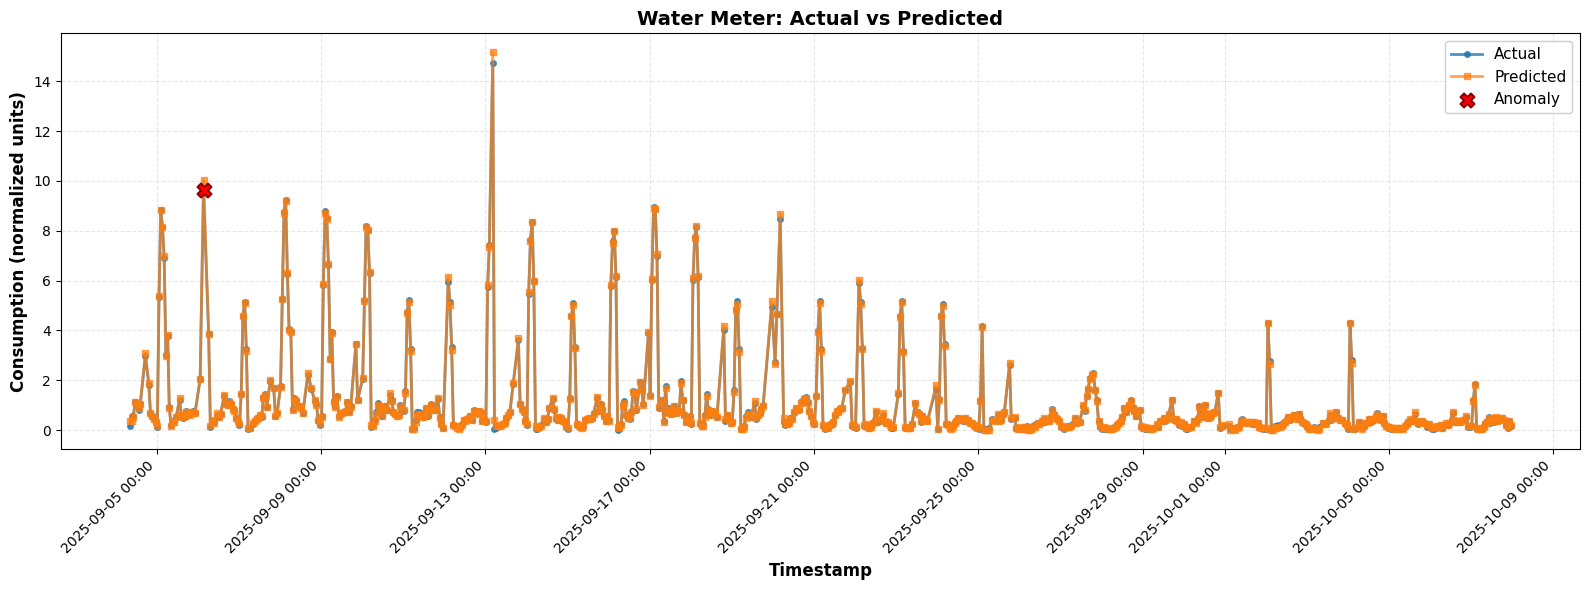

In [13]:
plot_predictions(results_df)

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'Water Meter: Actual vs Predicted\n(2025-09-05 to 2025-09-08)'}, xlabel='Timestamp', ylabel='Consumption (normalized units)'>)

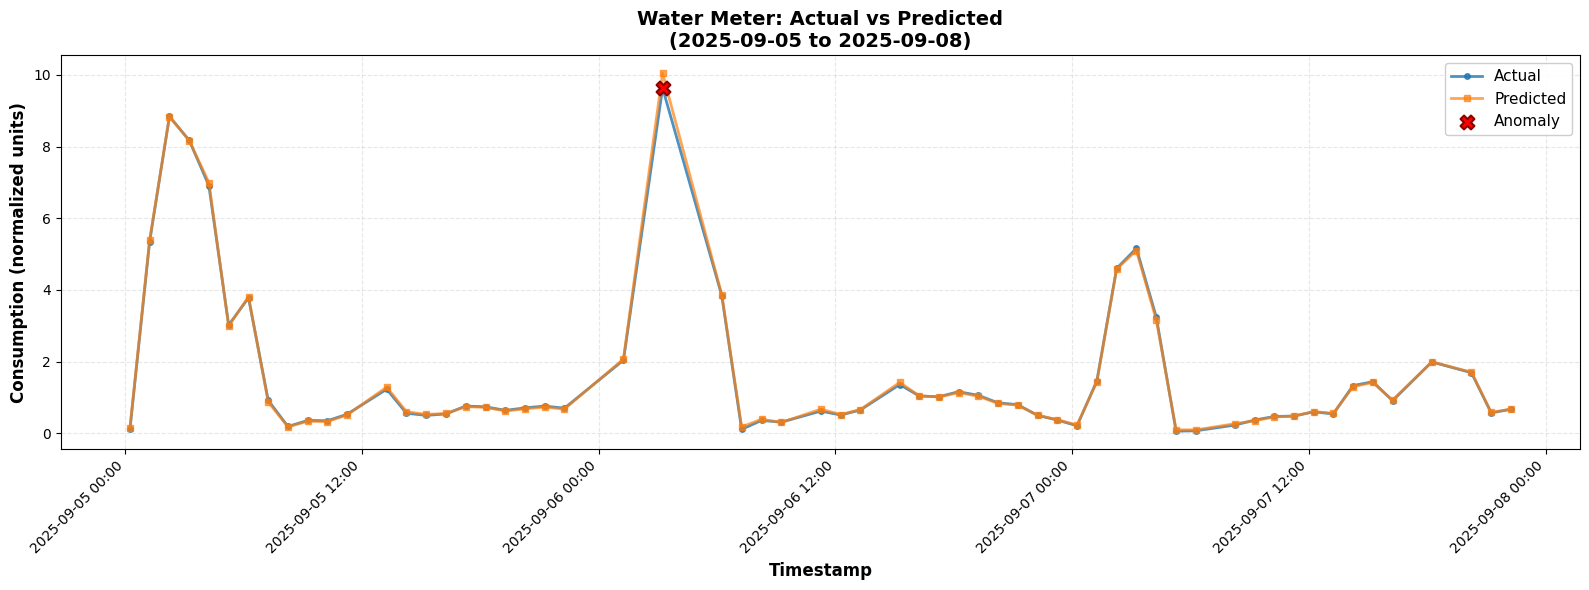

In [14]:
plot_predictions(results_df, date_range=('2025-09-05','2025-09-08'))